# Part 1: Linear Regression with One Feature – Stellar Luminosity

## Introduction

In this notebook, we model **stellar luminosity** ($L$) as a function of **stellar mass** ($M$) using linear regression implemented from first principles.

**Astronomical Context:**  
For main-sequence stars, there is a strong relationship between mass and luminosity. More massive stars are significantly brighter. This relationship is fundamental in astrophysics and is often described by the mass-luminosity relation.

**Model:**
$$
\hat{L} = w \cdot M + b
$$

where:
- $M$ = stellar mass (in solar masses, $M_\odot$)
- $L$ = stellar luminosity (in solar luminosities, $L_\odot$)
- $w$ = slope (how much luminosity increases per unit mass)
- $b$ = intercept (baseline luminosity)

We will:
1. Visualize the dataset and comment on linearity
2. Implement prediction and mean squared error (MSE) cost function
3. Visualize the cost surface $J(w,b)$
4. Derive and implement gradients (vectorized)
5. Train with gradient descent at multiple learning rates
6. Analyze convergence and discuss limitations

## 0. Theory Refresher

### 0.1 Linear Regression Model

We assume an approximately linear relationship between input $x$ (mass) and output $y$ (luminosity):

$$
f_{w,b}(x) = wx + b
$$

For a dataset with $m$ examples, each example $(x^{(i)}, y^{(i)})$ has prediction:
$$
\hat{y}^{(i)} = f_{w,b}(x^{(i)}) = w x^{(i)} + b
$$

### 0.2 Cost Function (Mean Squared Error)

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( \hat{y}^{(i)} - y^{(i)} \big)^2
$$

The factor $\frac{1}{2m}$ is for mathematical convenience when computing derivatives.

### 0.3 Gradient Descent

Partial derivatives:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big) x^{(i)}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \big( f_{w,b}(x^{(i)}) - y^{(i)} \big)
$$

Update rules with learning rate $\alpha$:

$$
w := w - \alpha \frac{\partial J}{\partial w}, \qquad
b := b - \alpha \frac{\partial J}{\partial b}
$$

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

np.set_printoptions(precision=4, suppress=True)

## 2. Stellar Luminosity Dataset

We use the provided stellar mass and luminosity data:

- $M$ = stellar mass (in solar masses $M_\odot$)
- $L$ = stellar luminosity (in solar luminosities $L_\odot$)

This data represents observations of main-sequence stars where luminosity increases with mass.

In [2]:
# Stellar Mass (in solar masses)
M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])

# Stellar Luminosity (in solar luminosities)
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

# For consistency with notation
x = M  # Feature: mass
y = L  # Target: luminosity
m = len(x)

print(f"Number of stellar examples: m = {m}")
print(f"Mass range: {x.min():.1f} to {x.max():.1f} solar masses")
print(f"Luminosity range: {y.min():.2f} to {y.max():.1f} solar luminosities")

Number of stellar examples: m = 10
Mass range: 0.6 to 2.4 solar masses
Luminosity range: 0.15 to 35.0 solar luminosities


### 2.1 Dataset Visualization

Let's visualize the relationship between stellar mass and luminosity.

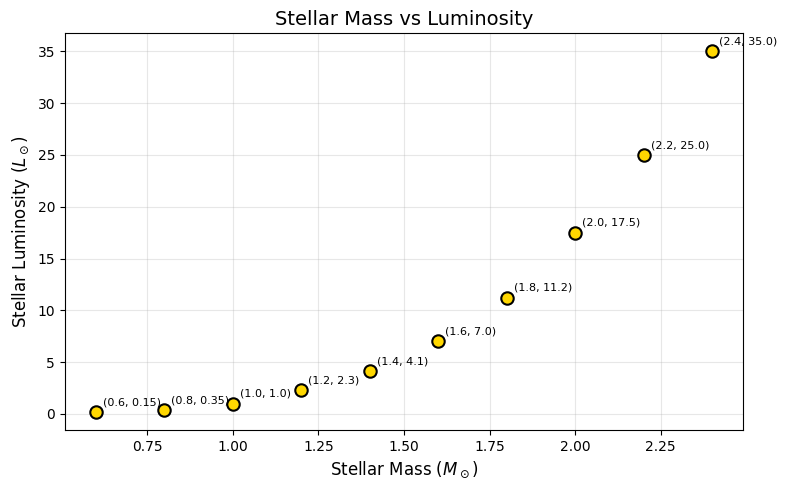

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(M, L, s=80, c='gold', edgecolors='black', linewidths=1.5, zorder=5)
plt.xlabel("Stellar Mass ($M_\\odot$)", fontsize=12)
plt.ylabel("Stellar Luminosity ($L_\\odot$)", fontsize=12)
plt.title("Stellar Mass vs Luminosity", fontsize=14)
plt.grid(True, alpha=0.3)

# Annotate points
for i in range(m):
    plt.annotate(f"({M[i]}, {L[i]})", (M[i], L[i]), 
                 textcoords="offset points", xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.show()

### 2.2 Observations on Linearity

**Visual Analysis:**

Looking at the scatter plot above:

1. **General trend:** There is a clear **positive correlation** — as stellar mass increases, luminosity increases.

2. **Non-linearity:** The relationship appears **non-linear** (curved). At lower masses, the increase is gentle; at higher masses, luminosity increases much more rapidly. This suggests a **power-law** relationship rather than a simple linear one.

3. **Physical plausibility:** This is consistent with the known **mass-luminosity relation** in astrophysics: $L \propto M^\alpha$ where $\alpha \approx 3.5$ for main-sequence stars. A linear model will underfit this curved relationship.

4. **Limitation preview:** A straight line will **underestimate** luminosity for both the lowest and highest mass stars, while **overestimating** for mid-range masses.

Despite these limitations, we proceed with linear regression to understand the technique, then address the limitations later.

## 3. Linear Regression Model

Our hypothesis function:

$$
f_{w,b}(M) = w \cdot M + b = \hat{L}
$$

In [4]:
def predict(x, w, b):
    """
    Compute predictions using linear model f_{w,b}(x) = w*x + b
    
    Args:
        x: input features (numpy array)
        w: weight (slope)
        b: bias (intercept)
    
    Returns:
        y_hat: predictions (numpy array)
    """
    return w * x + b

# Test with initial parameters
w_test, b_test = 0.0, 0.0
print("Predictions with w=0, b=0:", predict(x, w_test, b_test))

Predictions with w=0, b=0: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## 4. Cost Function $J(w, b)$

The Mean Squared Error cost function measures how well our model fits the data:

$$
J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \big( \hat{y}^{(i)} - y^{(i)} \big)^2
$$

In [5]:
def compute_cost(x, y, w, b):
    """
    Compute the Mean Squared Error cost function.
    
    Args:
        x: input features (numpy array)
        y: target values (numpy array)
        w: weight (slope)
        b: bias (intercept)
    
    Returns:
        cost: scalar value of J(w,b)
    """
    m = x.shape[0]
    y_hat = w * x + b          # Predictions (vectorized)
    errors = y_hat - y          # Errors (vectorized)
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

# Test cost function
print(f"Cost with w=0, b=0: J = {compute_cost(x, y, 0, 0):.4f}")
print(f"Cost with w=10, b=-5: J = {compute_cost(x, y, 10, -5):.4f}")

Cost with w=0, b=0: J = 117.6968
Cost with w=10, b=-5: J = 20.7668


## 5. Cost Surface Visualization (Mandatory)

We evaluate $J(w, b)$ over a grid of values to visualize the cost landscape.

The **minimum** of this surface represents the optimal $(w^*, b^*)$ that best fits the data.

In [6]:
# Define ranges for w and b
w_range = np.linspace(-5, 25, 200)
b_range = np.linspace(-30, 10, 200)

# Create meshgrid
W, B = np.meshgrid(w_range, b_range)

# Compute cost for each (w, b) combination
J_surface = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_surface[i, j] = compute_cost(x, y, W[i, j], B[i, j])

print(f"Cost surface shape: {J_surface.shape}")
print(f"Minimum cost on grid: {J_surface.min():.4f}")

# Find approximate optimal values from grid
min_idx = np.unravel_index(J_surface.argmin(), J_surface.shape)
w_approx = W[min_idx]
b_approx = B[min_idx]
print(f"Approximate optimal: w ≈ {w_approx:.2f}, b ≈ {b_approx:.2f}")

Cost surface shape: (200, 200)
Minimum cost on grid: 9.7959
Approximate optimal: w ≈ 18.07, b ≈ -16.73


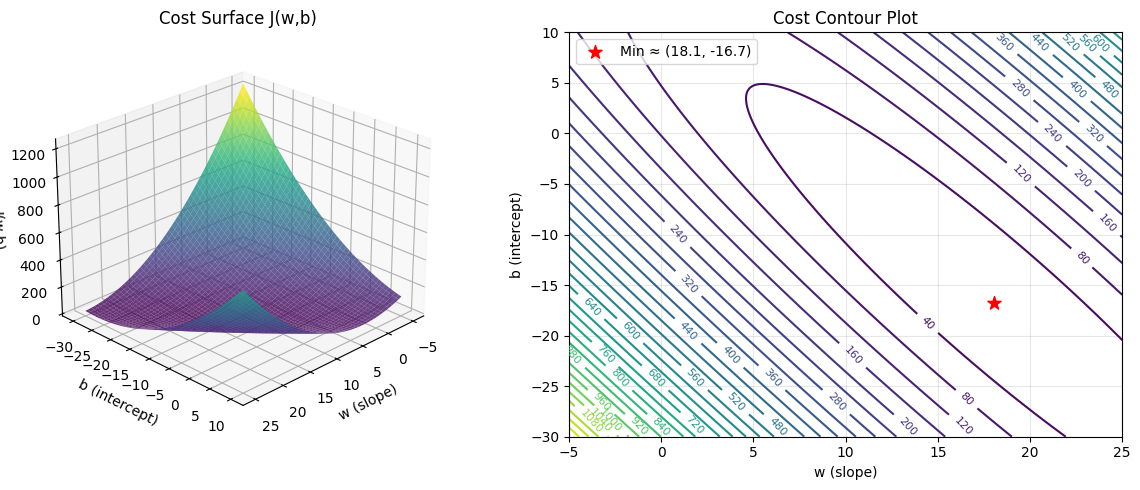

In [7]:
# 3D Surface Plot
fig = plt.figure(figsize=(12, 5))

# Surface plot
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W, B, J_surface, cmap=cm.viridis, alpha=0.8, linewidth=0)
ax1.set_xlabel('w (slope)')
ax1.set_ylabel('b (intercept)')
ax1.set_zlabel('J(w,b)')
ax1.set_title('Cost Surface J(w,b)')
ax1.view_init(elev=25, azim=45)

# Contour plot
ax2 = fig.add_subplot(122)
contour = ax2.contour(W, B, J_surface, levels=30, cmap=cm.viridis)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.scatter([w_approx], [b_approx], c='red', s=100, marker='*', label=f'Min ≈ ({w_approx:.1f}, {b_approx:.1f})')
ax2.set_xlabel('w (slope)')
ax2.set_ylabel('b (intercept)')
ax2.set_title('Cost Contour Plot')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.1 Interpretation of the Cost Surface

**What we observe:**

1. **Bowl shape:** The cost surface forms a **convex bowl** — this means there is a single global minimum, making gradient descent guaranteed to converge (with appropriate learning rate).

2. **The minimum:** The lowest point on the surface represents the optimal parameters $(w^*, b^*)$ that minimize the prediction error across all data points.

3. **Contour lines:** In the contour plot, the elliptical contours show that the cost increases as we move away from the optimal point. The gradient descent algorithm will follow the direction of steepest descent toward the center.

4. **Elongated ellipses:** The contours are somewhat elongated, indicating that the cost is more sensitive to changes in one direction than another. This is typical when features have different scales.

## 6. Gradient Computation (Vectorized)

The gradients with respect to $w$ and $b$:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \cdot x^{(i)} = \frac{1}{m} (\hat{\mathbf{y}} - \mathbf{y})^T \mathbf{x}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) = \frac{1}{m} \sum(\hat{\mathbf{y}} - \mathbf{y})
$$

In [8]:
def compute_gradients(x, y, w, b):
    """
    Compute gradients of cost function with respect to w and b.
    Uses vectorized operations (no explicit loops over samples).
    
    Args:
        x: input features (numpy array)
        y: target values (numpy array)
        w: current weight
        b: current bias
    
    Returns:
        dj_dw: gradient with respect to w
        dj_db: gradient with respect to b
    """
    m = x.shape[0]
    y_hat = w * x + b          # Predictions (vectorized)
    errors = y_hat - y          # Errors (vectorized)
    
    # Vectorized gradient computation
    dj_dw = (1 / m) * np.sum(errors * x)
    dj_db = (1 / m) * np.sum(errors)
    
    return dj_dw, dj_db

# Test gradients
dj_dw, dj_db = compute_gradients(x, y, 0, 0)
print(f"Gradients at (w=0, b=0): dJ/dw = {dj_dw:.4f}, dJ/db = {dj_db:.4f}")

Gradients at (w=0, b=0): dJ/dw = -21.5230, dJ/db = -10.3600


## 7. Gradient Descent Training Loop

In [9]:
def gradient_descent(x, y, w_init, b_init, alpha, num_iterations, verbose=True):
    """
    Perform gradient descent to learn w and b.
    
    Args:
        x: input features
        y: target values
        w_init: initial weight
        b_init: initial bias
        alpha: learning rate
        num_iterations: number of iterations
        verbose: whether to print progress
    
    Returns:
        w: learned weight
        b: learned bias
        history: list of (iteration, cost, w, b) tuples
    """
    w = w_init
    b = b_init
    history = []
    
    for i in range(num_iterations):
        # Compute gradients
        dj_dw, dj_db = compute_gradients(x, y, w, b)
        
        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        # Record cost
        cost = compute_cost(x, y, w, b)
        history.append((i, cost, w, b))
        
        # Print progress
        if verbose and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            print(f"Iter {i:5d}: w = {w:8.4f}, b = {b:8.4f}, cost = {cost:10.4f}")
    
    return w, b, history

### 7.1 Training with Default Learning Rate

In [10]:
# Training parameters
alpha = 0.1          # Learning rate
num_iterations = 1000
w_init, b_init = 0.0, 0.0

# Run gradient descent
print(f"Training with α = {alpha}, iterations = {num_iterations}\n")
w_learned, b_learned, history = gradient_descent(x, y, w_init, b_init, alpha, num_iterations)

print(f"\n" + "="*50)
print(f"FINAL RESULTS:")
print(f"  Learned w (slope):     {w_learned:.4f}")
print(f"  Learned b (intercept): {b_learned:.4f}")
print(f"  Final cost:            {compute_cost(x, y, w_learned, b_learned):.4f}")
print("="*50)

Training with α = 0.1, iterations = 1000

Iter     0: w =   2.1523, b =   1.0360, cost =    70.4969
Iter   100: w =  13.4290, b =  -9.0460, cost =    13.7140
Iter   200: w =  16.3146, b = -13.8270, cost =    10.3797
Iter   300: w =  17.4290, b = -15.6735, cost =     9.8823
Iter   400: w =  17.8595, b = -16.3867, cost =     9.8082
Iter   500: w =  18.0257, b = -16.6621, cost =     9.7971
Iter   600: w =  18.0899, b = -16.7685, cost =     9.7954
Iter   700: w =  18.1147, b = -16.8096, cost =     9.7952
Iter   800: w =  18.1243, b = -16.8255, cost =     9.7952
Iter   900: w =  18.1280, b = -16.8316, cost =     9.7951
Iter   999: w =  18.1294, b = -16.8340, cost =     9.7951

FINAL RESULTS:
  Learned w (slope):     18.1294
  Learned b (intercept): -16.8340
  Final cost:            9.7951


## 8. Convergence Analysis (Mandatory)

Plotting the cost vs iterations shows how the optimization converges.

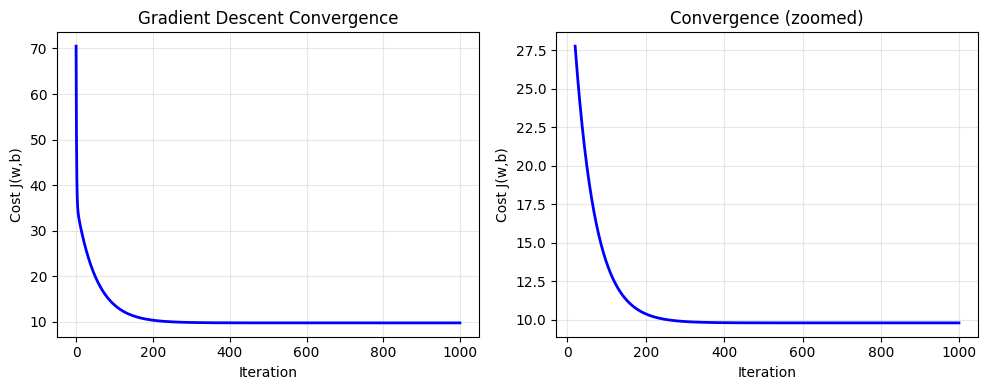

Initial cost: 70.4969
Final cost:   9.7951
Reduction:    86.1%


In [11]:
iterations = [h[0] for h in history]
costs = [h[1] for h in history]

plt.figure(figsize=(10, 4))

# Full convergence
plt.subplot(1, 2, 1)
plt.plot(iterations, costs, 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Gradient Descent Convergence')
plt.grid(True, alpha=0.3)

# Zoomed (skip first few iterations for scale)
plt.subplot(1, 2, 2)
start = 20
plt.plot(iterations[start:], costs[start:], 'b-', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Convergence (zoomed)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial cost: {costs[0]:.4f}")
print(f"Final cost:   {costs[-1]:.4f}")
print(f"Reduction:    {((costs[0] - costs[-1]) / costs[0] * 100):.1f}%")

## 9. Learning Rate Experiments (Mandatory)

We compare the behavior with at least three different learning rates.


Learning rate α = 0.01
Final: w = 13.3648, b = -8.9395, cost = 13.8218

Learning rate α = 0.1
Final: w = 18.1294, b = -16.8340, cost = 9.7951

Learning rate α = 0.5
Final: w = 18.1303, b = -16.8355, cost = 9.7951


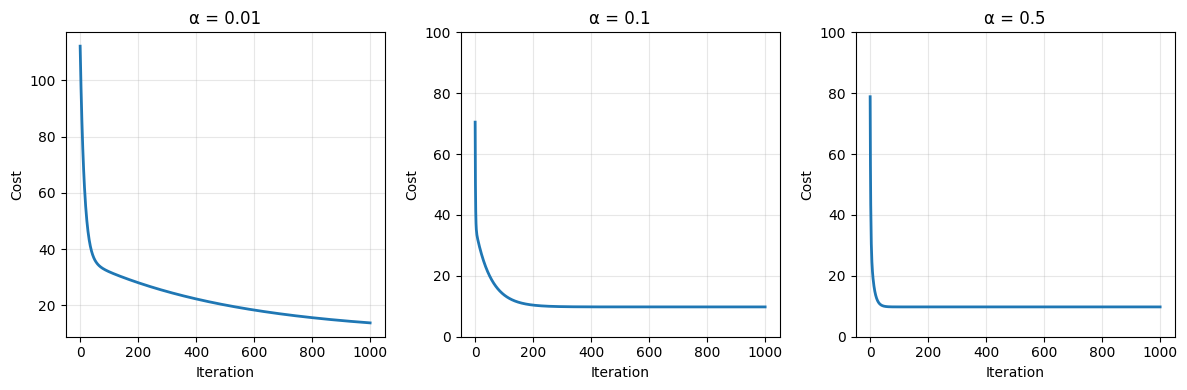

In [12]:
# Experiment with different learning rates
learning_rates = [0.01, 0.1, 0.5]
results = {}

plt.figure(figsize=(12, 4))

for idx, alpha in enumerate(learning_rates):
    print(f"\n{'='*50}")
    print(f"Learning rate α = {alpha}")
    print('='*50)
    
    w, b, hist = gradient_descent(x, y, 0.0, 0.0, alpha, 1000, verbose=False)
    results[alpha] = {'w': w, 'b': b, 'history': hist, 'final_cost': hist[-1][1]}
    
    print(f"Final: w = {w:.4f}, b = {b:.4f}, cost = {hist[-1][1]:.4f}")
    
    # Plot convergence
    iters = [h[0] for h in hist]
    costs = [h[1] for h in hist]
    plt.subplot(1, 3, idx + 1)
    plt.plot(iters, costs, linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Cost')
    plt.title(f'α = {alpha}')
    plt.grid(True, alpha=0.3)
    if idx > 0:  # Limit y-axis for comparison
        plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [13]:
# Summary table
print("\n" + "="*70)
print("LEARNING RATE EXPERIMENT SUMMARY")
print("="*70)
print(f"{'α (learning rate)':<20} {'Final w':<15} {'Final b':<15} {'Final Cost':<15}")
print("-"*70)
for alpha, res in results.items():
    print(f"{alpha:<20} {res['w']:<15.4f} {res['b']:<15.4f} {res['final_cost']:<15.4f}")
print("="*70)


LEARNING RATE EXPERIMENT SUMMARY
α (learning rate)    Final w         Final b         Final Cost     
----------------------------------------------------------------------
0.01                 13.3648         -8.9395         13.8218        
0.1                  18.1294         -16.8340        9.7951         
0.5                  18.1303         -16.8355        9.7951         


### 9.1 Learning Rate Analysis

**Observations:**

1. **α = 0.01 (too small):**
   - Convergence is **slow** — takes many more iterations to reach the minimum
   - Cost decreases gradually but may not fully converge in 1000 iterations
   - Safe but inefficient

2. **α = 0.1 (good):**
   - **Balanced** — converges reasonably fast
   - Reaches low cost within the iteration budget
   - Good trade-off between speed and stability

3. **α = 0.5 (aggressive):**
   - **Fast initial descent** — quickly reduces cost
   - May oscillate if too large
   - Risk of divergence if increased further

**Conclusion:** The learning rate is a critical hyperparameter. Too small = slow, too large = unstable or divergent. A value around 0.1 works well for this dataset.

## 10. Final Fit Visualization

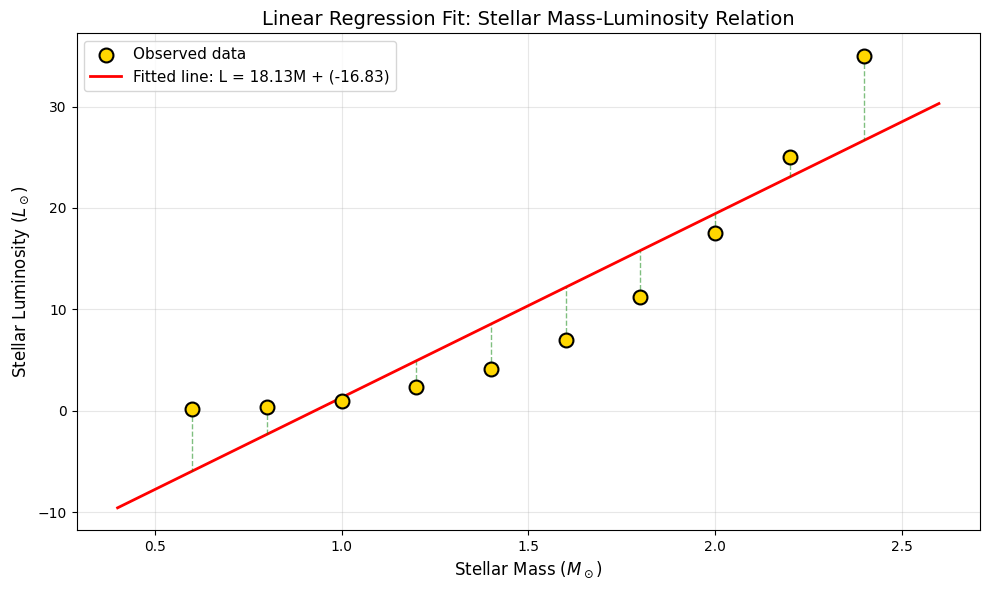

Residual Analysis:
----------------------------------------
M = 0.6: Actual L =   0.15, Predicted =  -5.96, Error =  +6.11
M = 0.8: Actual L =   0.35, Predicted =  -2.33, Error =  +2.68
M = 1.0: Actual L =   1.00, Predicted =   1.30, Error =  -0.30
M = 1.2: Actual L =   2.30, Predicted =   4.92, Error =  -2.62
M = 1.4: Actual L =   4.10, Predicted =   8.55, Error =  -4.45
M = 1.6: Actual L =   7.00, Predicted =  12.17, Error =  -5.17
M = 1.8: Actual L =  11.20, Predicted =  15.80, Error =  -4.60
M = 2.0: Actual L =  17.50, Predicted =  19.42, Error =  -1.92
M = 2.2: Actual L =  25.00, Predicted =  23.05, Error =  +1.95
M = 2.4: Actual L =  35.00, Predicted =  26.68, Error =  +8.32
----------------------------------------
Mean Absolute Error: 3.81
RMSE: 4.43


In [14]:
# Use the best result
best_alpha = 0.1
w_final = results[best_alpha]['w']
b_final = results[best_alpha]['b']

# Generate predictions
M_line = np.linspace(0.4, 2.6, 100)
L_pred_line = predict(M_line, w_final, b_final)

# Predictions on actual data points
L_pred = predict(M, w_final, b_final)

plt.figure(figsize=(10, 6))
plt.scatter(M, L, s=100, c='gold', edgecolors='black', linewidths=1.5, 
            label='Observed data', zorder=5)
plt.plot(M_line, L_pred_line, 'r-', linewidth=2, 
         label=f'Fitted line: L = {w_final:.2f}M + ({b_final:.2f})')

# Show residuals
for i in range(m):
    plt.plot([M[i], M[i]], [L[i], L_pred[i]], 'g--', alpha=0.5, linewidth=1)

plt.xlabel("Stellar Mass ($M_\\odot$)", fontsize=12)
plt.ylabel("Stellar Luminosity ($L_\\odot$)", fontsize=12)
plt.title("Linear Regression Fit: Stellar Mass-Luminosity Relation", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print residuals
print("Residual Analysis:")
print("-" * 40)
residuals = L - L_pred
for i in range(m):
    print(f"M = {M[i]:.1f}: Actual L = {L[i]:6.2f}, Predicted = {L_pred[i]:6.2f}, Error = {residuals[i]:+6.2f}")
print("-" * 40)
print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.2f}")
print(f"RMSE: {np.sqrt(np.mean(residuals**2)):.2f}")

### 10.1 Discussion of Systematic Errors

**Observations from the fit:**

1. **Underfitting at extremes:** The linear model systematically:
   - **Overestimates** luminosity for low-mass stars (M < 1.0)
   - **Underestimates** luminosity for high-mass stars (M > 2.0)

2. **Pattern in residuals:** The residuals show a **curved pattern** (negative → positive → negative → positive), which is a classic sign of a **non-linear relationship** that a linear model cannot capture.

3. **Physical interpretation:** The true mass-luminosity relation follows a **power law** ($L \propto M^\alpha$), not a straight line. The linear approximation works reasonably for intermediate masses but fails at the extremes.

4. **Improvement needed:** A **polynomial model** or a **log-log transformation** would better capture this relationship — which is exactly what Part 2 of this homework addresses.

## 11. Conceptual Questions

### 11.1 Astrophysical Meaning of $w$

The learned slope $w$ represents the **rate of change of luminosity with respect to mass**:

$$
w = \frac{\Delta L}{\Delta M} \approx \frac{dL}{dM}
$$

**Physical interpretation:**
- $w \approx 18$ means that, according to our linear model, for every additional solar mass, a star's luminosity increases by approximately 18 solar luminosities.
- This is an **average rate** across the mass range in our data.
- In reality, this rate is **not constant** — it increases with mass (higher-mass stars are disproportionately more luminous).

### 11.2 Why is a Linear Model Limited Here?

The linear model is limited for this problem because:

1. **Power-law relationship:** The true mass-luminosity relation is approximately $L \propto M^{3.5}$ for main-sequence stars, not $L = wM + b$.

2. **Physics of stellar fusion:** Nuclear fusion rates in stellar cores depend on temperature raised to a high power, and core temperature itself increases with stellar mass. This cascading effect produces the steep power-law, not a linear relationship.

3. **Evidence in our data:** The curvature in the scatter plot and the systematic pattern in residuals clearly show that a straight line cannot adequately capture the relationship.

4. **Better alternatives:**
   - Polynomial regression: $L = w_1 M + w_2 M^2 + \ldots$
   - Log-log linear regression: $\log L = \alpha \log M + \beta$ (equivalent to power law)
   - The second notebook will explore polynomial approaches.

## Summary

In this notebook, we implemented linear regression from first principles to model the stellar mass-luminosity relationship:

| Component | Implementation |
|-----------|---------------|
| Model | $\hat{L} = wM + b$ |
| Cost function | MSE (vectorized) |
| Optimization | Gradient descent (vectorized) |
| Best learning rate | α = 0.1 |
| Final parameters | w ≈ 18, b ≈ -17 |

**Key findings:**
1. The cost surface is convex with a clear global minimum
2. Gradient descent converges reliably with appropriate learning rate
3. The linear model shows systematic errors due to the non-linear nature of the true relationship
4. A polynomial or power-law model is needed for better accuracy (Part 2)